In [1]:
import os
import numpy as np
from scipy.stats import ks_2samp, ttest_ind
from collections import Counter, defaultdict
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False 

In [2]:
filepath = '../data/사내협력사 현황(철수사&거래 협력사)_ Data_송부_수정.xlsx'

In [3]:
df_raw_data_dict = pd.read_excel(filepath, sheet_name=None)
sheet_name_list = list(df_raw_data_dict.keys())

In [4]:
class Company:
    def __init__(self, company_id, catecory, subcategory, subsubcategory, start_date, end_date, label, data_duration):
        self.company_id = company_id
        self.catecory = catecory
        self.subcategory = subcategory
        self.subsubcategory = subsubcategory
        self.start_date = pd.to_datetime(start_date).replace(day=1) if pd.to_datetime(start_date) > pd.to_datetime('2016-02-01') else pd.to_datetime('2016-02-01')
        self.end_date = pd.to_datetime('2024-10-01') if end_date == '-' else pd.to_datetime(end_date).replace(day=1)
        self.duration = (self.end_date.year - self.start_date.year) * 12 + (self.end_date.month - self.start_date.month) + 1
        self.condition = True if self.duration >= data_duration or self.duration < 0 else False
        self.label = True if label == '경영악화' else False
        self.data_dict = dict()

In [15]:
df_temp = df_raw_data_dict[sheet_name_list[0]]
column = list(df_temp.columns)[:8]
get_all_data = False
start_date = pd.Timestamp('2016-02-01')
end_date = pd.Timestamp('2024-10-01')
expected_date_range = pd.date_range(start=start_date, end=end_date, freq='MS')
data_duration = 12
sheet_ban = ['4대보험 체납', '종합평가', '임금체불']
# sheet_ban = ['4대보험 체납', '종합평가', '임금체불', '4대보험 가입자', '본공률(4대보험)', '공수능률']
company_dict = dict()
for i, row in df_temp.iterrows():
    company_dict[row[column[0]]] = Company(row[column[0]], row[column[1]], row[column[2]], row[column[3]], row[column[4]], row[column[5]], row[column[7]], data_duration)

In [16]:
for sheet_name in sheet_name_list:
    if sheet_name in sheet_ban:
        print(sheet_name)
        continue
    else:
        df_temp = df_raw_data_dict[sheet_name]
        if pd.isna(pd.to_datetime(df_temp.columns[-1], errors='coerce')):
            df_temp = df_temp.iloc[:, :-1]
        new_cols = (list(df_temp.columns[:9]) + list(pd.to_datetime(df_temp.columns[9:]).map(lambda dt: dt.replace(day=1))))
        current_date_cols = new_cols[9:]
        
        if current_date_cols == list(expected_date_range):
            print(f"검증 결과: {sheet_name}의 new_cols가 expected_date_range와 정확히 일치합니다.")
        else:
            print(f"검증 결과: {sheet_name}의 new_cols가 expected_date_range와 일치하지 않습니다.")
            sheet_ban.append(sheet_name)
            continue
        df_temp.columns = new_cols
        df_raw_data_dict[sheet_name] = df_temp
        
        for i, row in df_temp.iterrows():
            if company_dict[i + 1].condition:
                if company_dict[i + 1].end_date not in df_temp.columns:
                    print(company_dict[i + 1].end_date)
                    continue
                if get_all_data:
                    # company_dict[i + 1].data_dict[sheet_name] = row[9:]
                    company_dict[i + 1].data_dict[sheet_name] = row[9:].where(
                        (row[9:].index >= company_dict[i + 1].start_date) & \
                         (row[9:].index <= company_dict[i + 1].end_date)
                    )
                else:
                    col_index = df_temp.columns.get_loc(company_dict[i + 1].end_date) + 1
                    company_dict[i + 1].data_dict[sheet_name] = row[col_index - data_duration:col_index].fillna(0)
            else:
                pass

검증 결과: 기성매출(정상기성)의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 공수능률의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 환산능률의 new_cols가 expected_date_range와 정확히 일치합니다.
임금체불
4대보험 체납
종합평가
검증 결과: 총원의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 입사율의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 입사자의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 퇴사율의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 퇴사자의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 본공률(시급월급)의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 시급,월급제 인원의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 본공률(4대보험)의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 4대보험 가입자의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 안전사고 건수(높음)의 new_cols가 expected_date_range와 정확히 일치합니다.
검증 결과: 안전사고 건수(중간, 낮음)의 new_cols가 expected_date_range와 정확히 일치합니다.


In [17]:
significant_pairs = []
unsignificant_pairs = []

for i in range(len(sheet_name_list)):
    for j in range(i + 1, len(sheet_name_list)):
        if sheet_name_list[i] in sheet_ban or sheet_name_list[j] in sheet_ban:
            continue
        sheet1 = sheet_name_list[i]
        sheet2 = sheet_name_list[j]

        correlations1 = []
        correlations2 = []
        
        error_count = 0
        for key, company in company_dict.items():
            if company.condition:
                x = company.data_dict[sheet1].to_numpy(dtype='float')
                y = company.data_dict[sheet2].to_numpy(dtype='float')
                if np.std(x) == 0 or np.std(y) == 0:
                    error_count += 1
                    continue
                corr = np.corrcoef(x, y)[0, 1]
                if company.label:
                    correlations1.append(np.round(corr, 3))
                else:
                    correlations2.append(np.round(corr, 3))
        
        if len(correlations1) >= 5 and len(correlations2) >= 5:
            ks_stat, ks_p = ks_2samp(correlations1, correlations2)
            t_stat, t_p = ttest_ind(correlations1, correlations2, equal_var=False)
            if ks_p < 0.05 or t_p < 0.05:
                significant_pairs.append({
                    'sheet1': sheet1,
                    'sheet2': sheet2,
                    'ks_p': round(ks_p, 4),
                    't_p': round(t_p, 4),
                    'n_경영악화': len(correlations1),
                    'n_정상': len(correlations2),
                    'error_count': error_count
                })
                
        else:
            unsignificant_pairs.append({
                'sheet1': sheet1,
                'sheet2': sheet2
            })

significant_df = pd.DataFrame(significant_pairs)
significant_df

,sheet1,sheet2,ks_p,t_p,n_경영악화,n_정상,error_count
0,기성매출(정상기성),총원,0.0000,0.0001,43,69,0
1,기성매출(정상기성),입사자,0.0446,0.0763,42,69,1
2,기성매출(정상기성),퇴사율,0.0065,0.0014,42,69,1
3,기성매출(정상기성),퇴사자,0.0198,0.0066,42,69,1
4,기성매출(정상기성),본공률(시급월급),0.0079,0.3725,42,63,7
5,기성매출(정상기성),"시급,월급제 인원",0.0000,0.0002,43,69,0
6,공수능률,환산능률,0.0045,0.2238,43,69,0
7,환산능률,총원,0.0746,0.0313,43,69,0
8,환산능률,퇴사율,0.0219,0.1616,42,69,1
9,환산능률,퇴사자,0.0446,0.2151,42,69,1


In [18]:
correlation1 = []
correlation2 = []
error_count = 0
for key, company in company_dict.items():
    if company.condition:
        x = company.data_dict[sheet_name_list[0]].to_numpy(dtype='float')
        y = company.data_dict[sheet_name_list[6]].to_numpy(dtype='float')
        if np.std(x) == 0 or np.std(y) == 0:
            error_count += 1
            continue
        corr = np.corrcoef(x, y)[0, 1]
        if company.label:
            correlations1.append(np.round(corr, 3))
        else:
            correlations2.append(np.round(corr, 3))

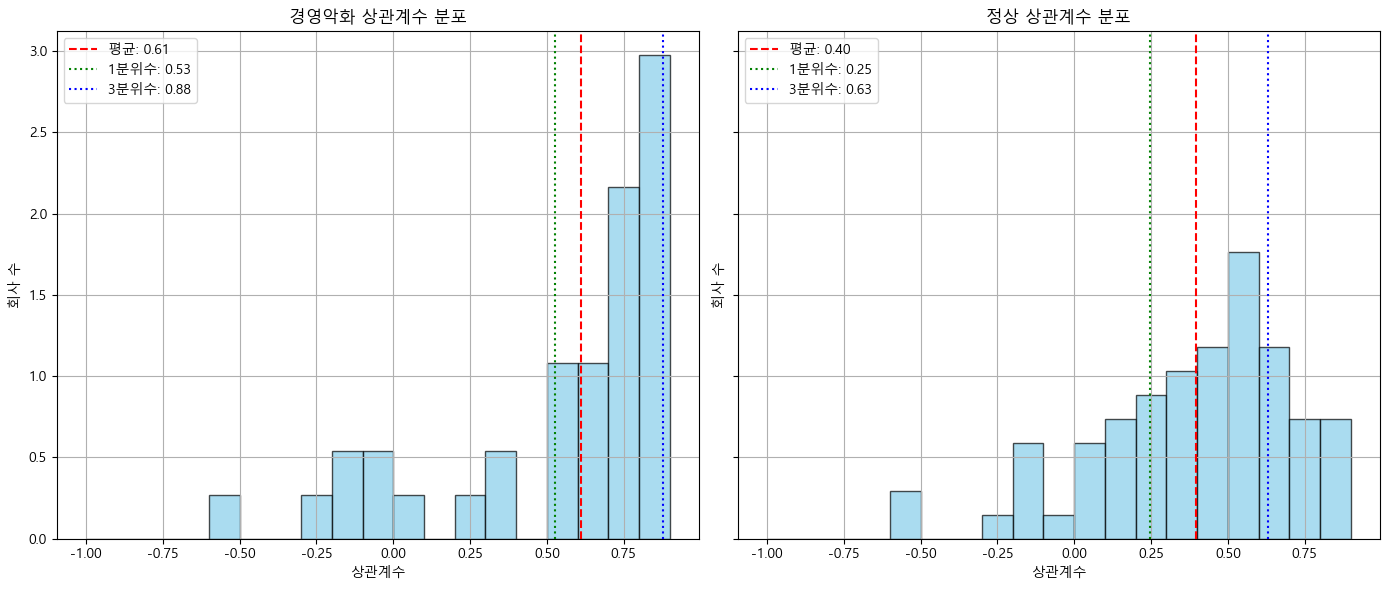

In [19]:
# bins 설정
bins = np.arange(-1.0, 1.0, 0.1)

# 시각화 시작
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 데이터와 라벨 묶기
datasets = [(correlations1, '경영악화'), (correlations2, '정상')]

for ax, (data, label) in zip(axes, datasets):
    # 히스토그램
    ax.hist(data, bins=bins, alpha=0.7, edgecolor='black', color='skyblue', density=True)
    ax.set_title(f'{label} 상관계수 분포')
    ax.set_xlabel('상관계수')
    ax.set_ylabel('회사 수')
    ax.grid(True)

    # 통계 지표
    mean = np.mean(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    # 수직선 표시
    ax.axvline(mean, color='red', linestyle='--', label=f'평균: {mean:.2f}')
    ax.axvline(q1, color='green', linestyle=':', label=f'1분위수: {q1:.2f}')
    ax.axvline(q3, color='blue', linestyle=':', label=f'3분위수: {q3:.2f}')
    ax.legend()

plt.tight_layout()
plt.savefig('correlation.png', dpi=1000, bbox_inches='tight')
plt.show()


In [20]:
# 유의미한 쌍 수 계산
count_1 = Counter(significant_df['sheet1'])
count_2 = Counter(significant_df['sheet2'])
total_count = count_1 + count_2

# 어떤 시트와 유의미했는지 저장
related_sheets = defaultdict(set)
for _, row in significant_df.iterrows():
    s1, s2 = row['sheet1'], row['sheet2']
    related_sheets[s1].add(s2)
    related_sheets[s2].add(s1)

# 데이터프레임 구성
sheet_count_df = pd.DataFrame.from_dict(
    total_count, orient='index', columns=['유의미한 쌍 개수']
).sort_values(by='유의미한 쌍 개수', ascending=False)

# 오른쪽 열에 유의미한 시트 이름 추가
sheet_count_df['연관된 시트들'] = sheet_count_df.index.map(
    lambda sheet: ', '.join(sorted(related_sheets[sheet]))
)

sheet_count_df.index.name = 'sheet_name'
sheet_count_df.reset_index(inplace=True)
sheet_count_df

,sheet_name,유의미한 쌍 개수,연관된 시트들
0,"시급,월급제 인원",8,"4대보험 가입자, 기성매출(정상기성), 본공률(시급월급), 입사자, 총원, 퇴사율,..."
1,퇴사율,7,"기성매출(정상기성), 본공률(시급월급), 시급,월급제 인원, 입사율, 입사자, 총원..."
2,기성매출(정상기성),6,"본공률(시급월급), 시급,월급제 인원, 입사자, 총원, 퇴사율, 퇴사자"
3,환산능률,6,"공수능률, 본공률(시급월급), 시급,월급제 인원, 총원, 퇴사율, 퇴사자"
4,입사자,6,"기성매출(정상기성), 본공률(시급월급), 시급,월급제 인원, 입사율, 퇴사율, 퇴사자"
5,퇴사자,6,"기성매출(정상기성), 시급,월급제 인원, 입사율, 입사자, 총원, 환산능률"
6,총원,5,"기성매출(정상기성), 시급,월급제 인원, 퇴사율, 퇴사자, 환산능률"
7,본공률(시급월급),5,"기성매출(정상기성), 시급,월급제 인원, 입사자, 퇴사율, 환산능률"
8,입사율,3,"입사자, 퇴사율, 퇴사자"
9,4대보험 가입자,2,"본공률(4대보험), 시급,월급제 인원"


In [21]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 결과를 저장할 딕셔너리 (feature별 모델 결과 저장)
results = {}

# 각 시트를 feature라고 가정하고, 분석 대상 시트 리스트를 sheet_name_list에 담습니다.
for sheet_name in sheet_name_list:
    data_records = []
    
    # 각 회사의 해당 feature(시트)에 대한 시계열 데이터를 합칩니다.
    for company_id, company in company_dict.items():
        # 해당 회사에 해당 feature 데이터가 존재하는 경우
        if sheet_name in company.data_dict:
            ts_data = company.data_dict[sheet_name]
            # ts_data의 인덱스는 날짜(Timestamp)라고 가정합니다.
            # 시계열 데이터의 값이 NaN인 경우는 관측 기간 외(회사 시작 전 또는 종료 후)로 남아있습니다.
            for date, value in ts_data.items():
                data_records.append({
                    'company_id': company_id,
                    'date': date,          # 각 관측일자 (pd.Timestamp)
                    'value': value,        # 해당 시점의 측정값, 관측되지 않은 기간은 NaN
                    'label': company.label # 0 혹은 1
                })
    
    # 데이터가 없는 시트는 건너뜁니다.
    if not data_records:
        print(f"{sheet_name} 시트에는 데이터가 없습니다.")
        continue

    # DataFrame 생성
    df_feature = pd.DataFrame(data_records)
    df_feature['date'] = pd.to_datetime(df_feature['date'])
    df_feature.sort_values('date', inplace=True)
    
    # 각 회사의 상대 시간을 계산합니다.
    # 예를 들어, 해당 시계열 데이터의 최소 날짜를 기준으로 경과한 개월 수를 계산.
    min_date = df_feature['date'].min()
    df_feature['Time'] = (df_feature['date'] - min_date).dt.days / 30.0

    # label은 범주형으로 처리합니다.
    df_feature['label'] = df_feature['label'].astype('category')
    
    # NaN 값이 있는 행은 모델 적합 전에 제거됩니다.
    df_model = df_feature.dropna(subset=['value'])
    
    # 혼합효과 모델 적합: 고정 효과로 Time, label, 그리고 그 상호작용(Time:label)을 포함하고,
    # 회사별 고유 효과를 랜덤 효과로 모델에 반영합니다.
    # 모델 식: value ~ Time + label + Time:label
    model = smf.mixedlm("value ~ Time * label", df_model, groups=df_model["company_id"])
    result = model.fit()
    
    results[sheet_name] = result
    # print(df_feature)
    print(f"===== {sheet_name} Feature Model Summary =====")
    print(result.summary())
    break

===== 기성매출(정상기성) Feature Model Summary =====
              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    value     
No. Observations:     1344       Method:                REML      
No. Groups:           112        Scale:                 19192.0220
Min. group size:      12         Log-Likelihood:        -8751.5822
Max. group size:      12         Converged:             Yes       
Mean group size:      12.0                                        
------------------------------------------------------------------
                     Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept            456.560  126.273  3.616 0.000 209.070 704.050
label[T.True]        355.708  153.916  2.311 0.021  54.038 657.378
Time                   2.953    1.374  2.150 0.032   0.261   5.645
Time:label[T.True]    -9.987    1.986 -5.029 0.000 -13.879  -6.094
Group Var          97149.695  10

In [22]:
df_temp = df_raw_data_dict[sheet_name_list[0]]


In [23]:
grouped = df_temp.groupby([df_temp.columns[2], df_temp.columns[7]]).size()
for category, group in grouped.groupby(level=0):
    total = group.sum()
    label_str = ", ".join([f"{idx[1]}: {count}개" for idx, count in group.items()])
    gyeong_count = group.get((category, "경영악화"), 0)
    gyeong_percent = (gyeong_count / total * 100) if total > 0 else 0
    print(f"{category} | {label_str} | 총합: {total}개 | 경영악화: {gyeong_percent:.1f}%")

협력1 | 거래중: 25개, 경영악화: 24개 | 총합: 49개 | 경영악화: 49.0%
협력2 | 거래중: 44개, 경영악화: 17개 | 총합: 61개 | 경영악화: 27.9%
협력3 | 거래중: 14개, 경영악화: 3개 | 총합: 17개 | 경영악화: 17.6%


In [24]:
grouped = df_temp.groupby([df_temp.columns[3], df_temp.columns[7]]).size()
for category, group in grouped.groupby(level=0):
    total = group.sum()
    label_str = ", ".join([f"{idx[1]}: {count}개" for idx, count in group.items()])
    gyeong_count = group.get((category, "경영악화"), 0)
    gyeong_percent = (gyeong_count / total * 100) if total > 0 else 0
    print(f"{category} | {label_str} | 총합: {total}개 | 경영악화: {gyeong_percent:.1f}%")

공사 | 거래중: 7개, 경영악화: 5개 | 총합: 12개 | 경영악화: 41.7%
공장1 | 거래중: 1개 | 총합: 1개 | 경영악화: 0.0%
공장2 | 거래중: 2개 | 총합: 2개 | 경영악화: 0.0%
공장3 | 거래중: 16개, 경영악화: 4개 | 총합: 20개 | 경영악화: 20.0%
기타 | 거래중: 2개 | 총합: 2개 | 경영악화: 0.0%
내장1 | 거래중: 1개 | 총합: 1개 | 경영악화: 0.0%
내장2 | 거래중: 3개, 경영악화: 2개 | 총합: 5개 | 경영악화: 40.0%
내장3 | 경영악화: 1개 | 총합: 1개 | 경영악화: 100.0%
내장4 | 거래중: 2개 | 총합: 2개 | 경영악화: 0.0%
도크 | 거래중: 11개, 경영악화: 6개 | 총합: 17개 | 경영악화: 35.3%
라인1 | 거래중: 10개, 경영악화: 11개 | 총합: 21개 | 경영악화: 52.4%
라인2 | 거래중: 7개, 경영악화: 7개 | 총합: 14개 | 경영악화: 50.0%
시험 | 거래중: 2개 | 총합: 2개 | 경영악화: 0.0%
외장1 | 거래중: 3개 | 총합: 3개 | 경영악화: 0.0%
외장2 | 거래중: 1개 | 총합: 1개 | 경영악화: 0.0%
외장3 | 거래중: 6개, 경영악화: 1개 | 총합: 7개 | 경영악화: 14.3%
외장4 | 거래중: 4개, 경영악화: 2개 | 총합: 6개 | 경영악화: 33.3%
지원 | 거래중: 5개, 경영악화: 5개 | 총합: 10개 | 경영악화: 50.0%
